<a href="https://colab.research.google.com/github/Medrodi/MIIGAIK-Computer-Math/blob/main/10.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F%20%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2%20%D0%B8%20%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F%20%D0%A4%D1%83%D1%80%D1%8C%D0%B5%20/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D0%B8_%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F_%D0%A4%D1%83%D1%80%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Генерация сигналов и преобразования Фурье**

# Блок №1. Базовый уровень

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import spectrogram

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



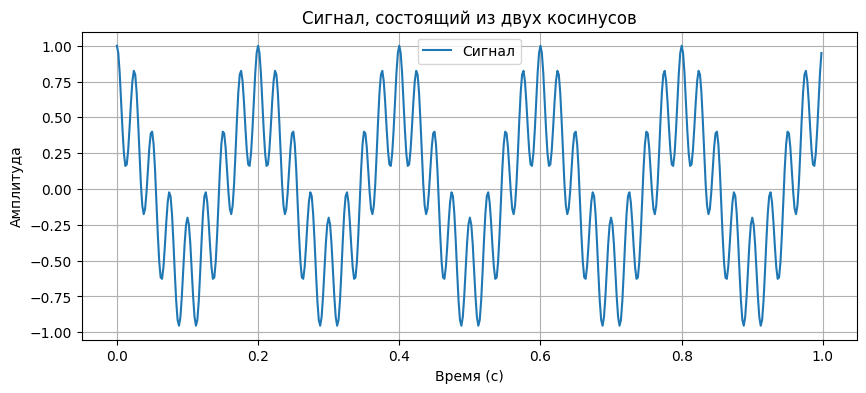

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

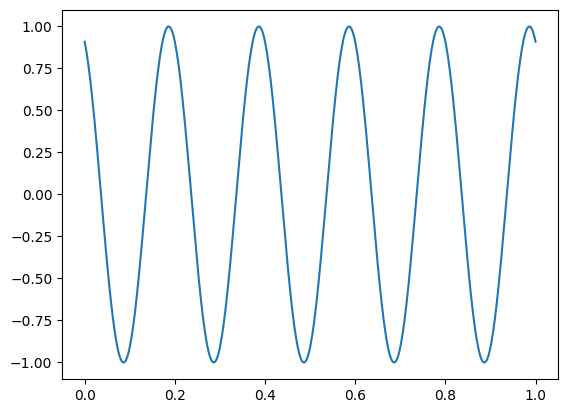

In [ ]:
t = np.linspace(0, 1, fs)

# Создание сигнала
f = 5.0
a = 1
fi = 2
sin_signal = a*np.sin(2*np.pi*f*t+fi)

fig, ax = plt.subplots()
ax.plot(t, sin_signal)

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

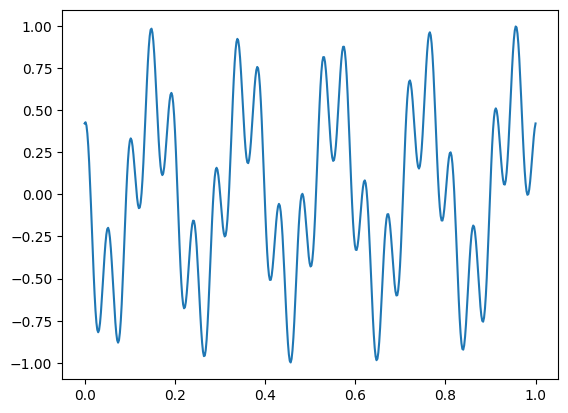

In [ ]:
# Создание сигнала
f1 = 5.0
f2 = 21.0
a1 = 0.6
a2 = 0.4
fi1 = 3
fi2 =1
sum_sin_signal = a1*np.sin(2*np.pi*f1*t + fi1) + a2*np.sin(2*np.pi*f2*t+fi2)

fig, ax = plt.subplots()
ax.plot(t, sum_sin_signal)

3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

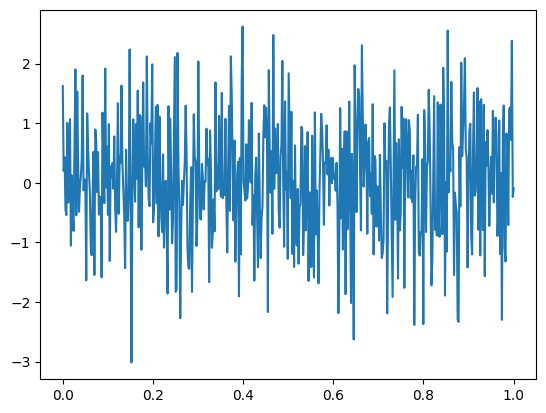

In [ ]:
noise = np.random.normal(0, 1, size=500)

T = 1
t = np.linspace(0, 1, fs)

# Создание сигнала
f = 2.0
a = 0.6
fi = 2
noise_signal = noise*T

fig, ax = plt.subplots()
ax.plot(t, noise_signal)

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

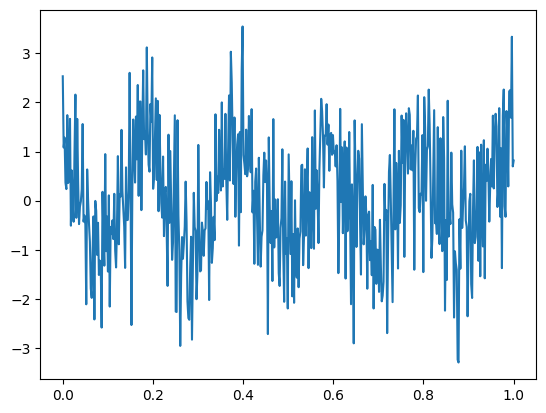

In [ ]:
noise_sin_signal = noise_signal + sin_signal

fig, ax = plt.subplots()
ax.plot(t, noise_sin_signal)


## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


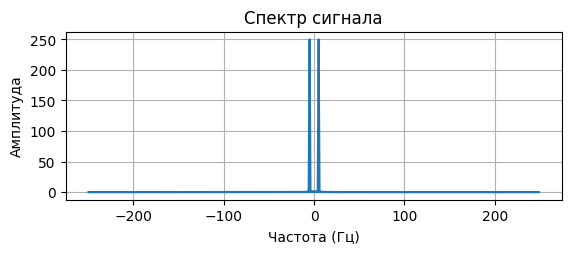

In [ ]:
fft_result = fft(sin_signal)
frequencies = fftfreq(len(t), 1 / fs)  # Частоты

plt.subplot(2, 1, 2)
plt.plot(frequencies, np.abs(fft_result))  # Положительные частоты
plt.title("Спектр сигнала")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid()

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


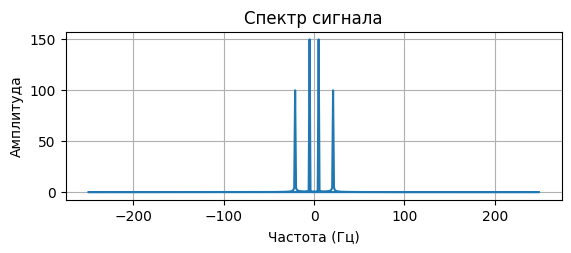

In [ ]:
fft_result = fft(sum_sin_signal)
frequencies = fftfreq(len(t), 1 / fs)  # Частоты

plt.subplot(2, 1, 2)
plt.plot(frequencies, np.abs(fft_result))  # Положительные частоты
plt.title("Спектр сигнала")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid()

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


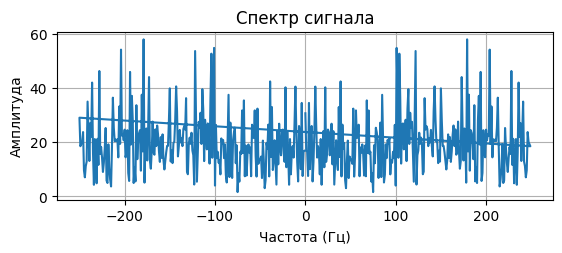

In [ ]:
fft_result = fft(noise_signal)
frequencies = fftfreq(len(t), 1 / fs)  # Частоты

plt.subplot(2, 1, 2)
plt.plot(frequencies, np.abs(fft_result))  # Положительные частоты
plt.title("Спектр сигнала")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid()

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

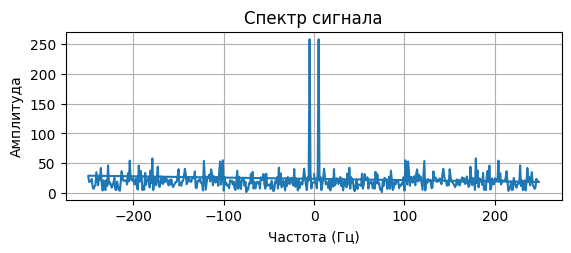

In [ ]:
fft_result = fft(noise_sin_signal)
frequencies = fftfreq(len(t), 1 / fs)  # Частоты

plt.subplot(2, 1, 2)
plt.plot(frequencies, np.abs(fft_result))  # Положительные частоты
plt.title("Спектр сигнала")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid()

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

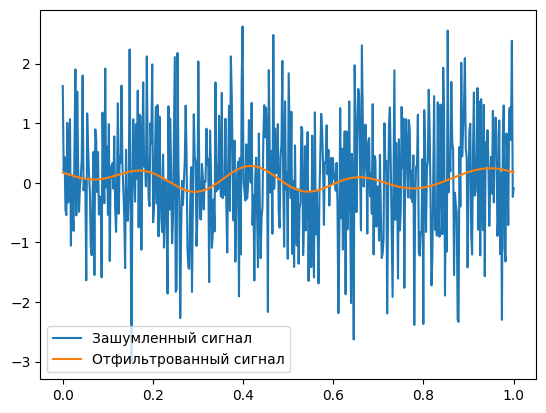

In [ ]:
def clean_f(signal, cut_frequency):
  n = len(signal)
  spectrum = fft(signal)
  frequencies = fftfreq(n, d=1/fs)
  spectrum[np.abs(frequencies) > cut_frequency] = 0
  filtered_signal = ifft(spectrum).real
  return filtered_signal

filtered_signal = clean_f(noise_signal, 5)
plt.plot(t, noise_signal, label='Зашумленный сигнал')
plt.plot(t, filtered_signal, label='Отфильтрованный сигнал')
plt.legend()
plt.show()

2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

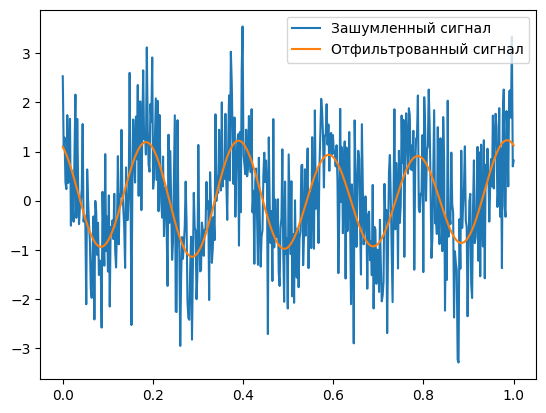

In [ ]:
filtered_noise_sin_signal = clean_f(noise_sin_signal, 5)
plt.plot(t, noise_sin_signal, label='Зашумленный сигнал')
plt.plot(t, filtered_noise_sin_signal, label='Отфильтрованный сигнал')
plt.legend()
plt.show()

## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


In [ ]:
def sig_to_spectr(signal):
  f, t_spec, Sxx = spectrogram(signal)
  plt.pcolormesh(t_spec, f, Sxx, shading='gouraud')
  plt.ylabel('Frequency [Hz]')
  plt.xlabel('Time [sec]')
  plt.colorbar(label='Intensity [dB]')
  plt.show()

2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

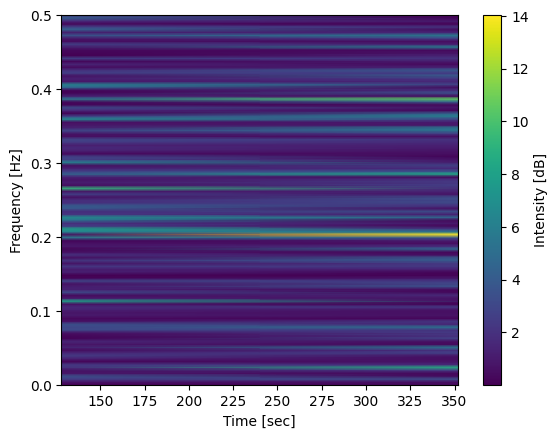

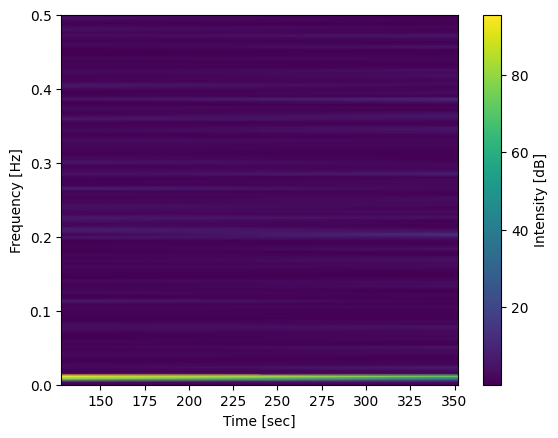

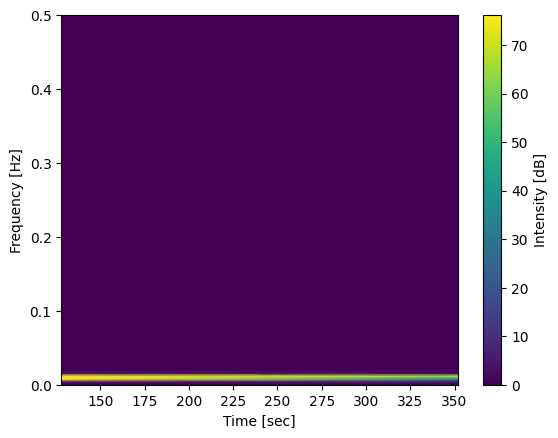

In [ ]:
noise_spectr = sig_to_spectr(noise_signal)
noise_sin_spectr = sig_to_spectr(noise_sin_signal)
filtered_noise_sin_spectr = sig_to_spectr(filtered_noise_sin_signal)

# Блок №2. Повышенный уровень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.io import wavfile



## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [2]:
fs, signal = wavfile.read("Vivaldi.wav")
if len(signal.shape) > 1:
    signal = signal[:, 0]

2. Визуализируйте временную форму звукового сигнала.

Text(0, 0.5, 'Amplitude')

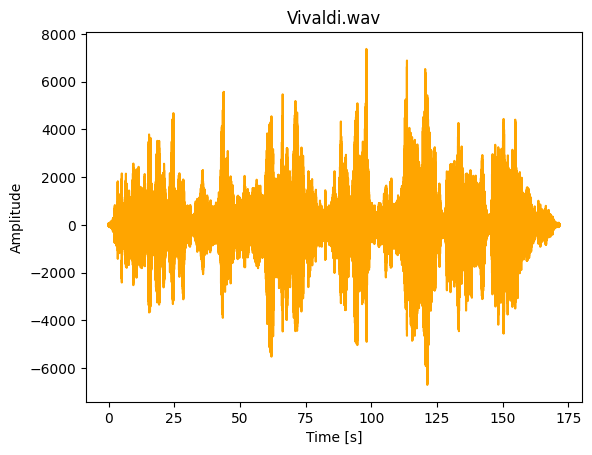

In [3]:
duration = len(signal) / fs
t = np.linspace(0, duration, len(signal))

plt.plot(t, signal, color='orange')
plt.title("Vivaldi.wav")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

In [ ]:
# Пример

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

Text(0, 0.5, 'Magnitude')

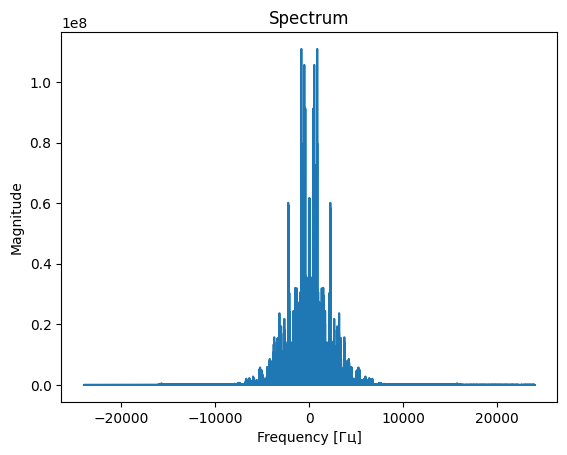

In [4]:

fft_result = fft(signal)
frequencies = fftfreq(len(signal), 1 / fs)
amplitude_spectrum = np.abs(fft_result)

plt.plot(frequencies, amplitude_spectrum)
plt.title('Spectrum')
plt.xlabel('Frequency [Гц]')
plt.ylabel('Magnitude')

In [ ]:
# Пример

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [5]:
def clean_f(signal, cut_frequency):
  spectrum = fft(signal)
  frequencies = fftfreq(len(signal), d=1/fs)
  spectrum[np.abs(frequencies) > cut_frequency] = 0
  filtered_signal = ifft(spectrum).real

  plt.plot(t, filtered_signal, color='orange')
  plt.title("Vivaldi.wav после фильтрации")
  plt.xlabel('Time [s]')
  plt.ylabel('Amplitude')

  return filtered_signal

2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

Text(0, 0.5, 'Amplitude')

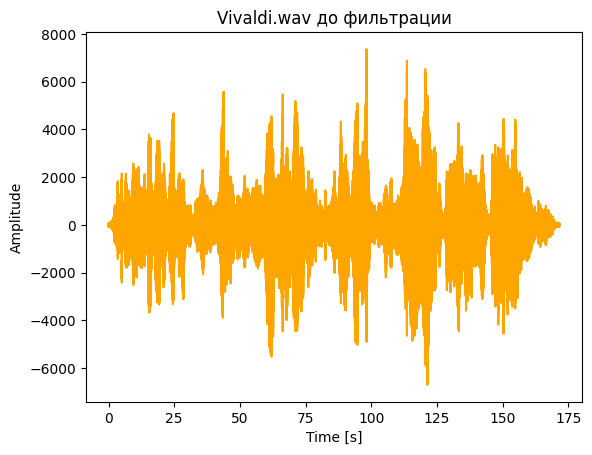

In [7]:
plt.plot(t, signal, color='orange')
plt.title("Vivaldi.wav до фильтрации")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

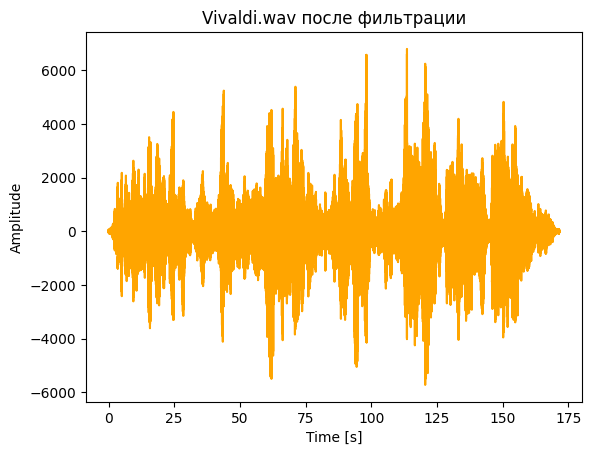

In [16]:
filtered_music = clean_f(signal, 3000)

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [23]:
spectrum = fft(signal)
frequencies = fftfreq(len(signal), d=1/fs)
spectrum[np.abs(frequencies) > 3000] = 0
filtered_signal = ifft(spectrum).real
filtered_audio_int = np.int16(filtered_signal)

2. Сохраните полученный сигнал в новый звуковой файл.

In [24]:
wavfile.write("converted_filtered_audio.wav", fs, filtered_audio_int)

In [25]:
from google.colab import files
files.download("converted_filtered_audio.wav")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>